## Foundations of the Predictive Architecture
The success of a machine learning model depends on the quality of its environment. For our study in Brazzaville, we select specialized libraries that transform raw student profiles into mathematical insights. This digital ecosystem ensures the stability of our Gradient Boosting Machine while providing the metrics required for a rigorous validation. We rely on the following pillars to build our predictive oracle.
- **The gbm** library handles the iterative construction of decision trees by minimizing errors through successive gradients.
- **The caret package** provides a unified framework for data partitioning and hyperparameter tuning to ensure the model generalizes well to the Congolese context.
- **The pROC tool** enables the calculation of the Area Under the Curve to measure the classifier's ability to distinguish between academic success and failure.

In [1]:
# Installing the core Gradient Boosting Machine engine
install.packages("gbm")

# Installing the Classification and REgression Training framework
install.packages("caret")

# Installing the tools for Receiver Operating Characteristic analysis
install.packages("pROC")

# Installing the necessary library for Excel files
install.packages("readxl")

- Querying repositories for available source packages ... Done!
The following package(s) will be installed:
- gbm [2.2.3]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ gbm 2.2.3                                [linked from cache]
The following package(s) will be installed:
- caret [7.0-1]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ caret 7.0-1                              [linked from cache]
The following package(s) will be installed:
- pROC [1.19.0.1]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages ------------------------------------

In [2]:
# Loading the libraries into the current Jupyter session
library(gbm)
library(caret)
library(pROC)
library(readxl)

Loaded gbm 2.2.3

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3

Loading required package: ggplot2

Loading required package: lattice

Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var




### Preparing the dataset

In [3]:
# Importing the Excel file into a data frame named 'student_data'
# We ensure the file path matches your local directory structure

student_data <- read_excel("data_src_2.xlsx")


# Identifying the number of missing values (NA) per column
# This overview highlights variables with data collection gaps

colSums(is.na(student_data))

# Strategy for numeric variables: Replacing NAs with the median
# This maintains the distribution without losing valuable student profiles

for(i in 1:ncol(student_data)) {
  if(is.numeric(student_data[[i]])) {
    student_data[[i]][is.na(student_data[[i]])] <- median(student_data[[i]], na.rm = TRUE)
  }
}

# Final check to ensure the dataset is now complete
# sum(is.na(student_data))

# Assuming 'Pass' becomes 1 and 'Fail' becomes 0
# You should adapt the strings "Pass" and "Fail" to match your exact data entries
student_data$Result_Binary <- ifelse(student_data$Result == "Pass", 1, 0)

# Processing Binary Variables
# Converting the gender variable into a binary indicator for mathematical stability

student_data$gender <- ifelse(student_data$gender == "Male", 1, 0)

# Managing Missing Values for the Device Column
# We fill gaps with "None" to represent students without digital access

student_data$device[is.na(student_data$device)] <- "None"

# Implementing One-Hot Encoding for Multi-Category Factors
# This method expands the matrix to include specific vectors for every category

# Selecting variables for the transformation based on the actual dataset headers
categorical_vars <- c("language", "stream", "device", "Independent_study", "class_size")

# Using the dummyVars function to create the expansion model
encoder_model <- dummyVars(~ language + stream + device + Independent_study + class_size, data = student_data)
encoded_features <- data.frame(predict(encoder_model, newdata = student_data))

# Merging the new numerical vectors with the main dataset
# We drop the original text columns to ensure the final matrix is purely numerical

columns_to_remove <- c(categorical_vars, "student_id", "school_id", "sn")
student_data_final <- cbind(student_data[, !(names(student_data) %in% columns_to_remove)], encoded_features)

# Final structural audit to confirm the numerical readiness
str(student_data_final)




sn                  student_id 
                          0                           0 
                  school_id     power_cut_hour_per_week 
                          0                           0 
            study_during_pc      study_quiet_place_1_10 
                          0                           0 
study_interruption_per_hour        sleep_hour_per_night 
                          0                           0 
         sleep_quality_1_10                 stress_1_10 
                          0                           0 
          technostress_1_10         cognitive_load_1_10 
                          0                           0 
            resilience_1_10 digital_education_hour_week 
                          0                           0 
      social_media_hour_day                      device 
                          0                           0 
             ai_use_req_1_5            commute_hour_day 
                          0                           0 
    hour_searching_per_week           active_recall_1_5 
                          0                           0 
         self_test_per_week           Independent_study 
                          0                           0 
    past_test_hour_per_week                       tutor 
                          0                           0 
        tutor_hour_per_week           spaced_repetition 
                          0                           0 
               absence_days    instruction_clarity_1_10 
                          0                           0 
                     gender                         age 
                          0                           0 
                   language                      stream 
                          0                           0 
                 class_size          chore_hour_per_day 
                          0                           0 
                 mock_score                      Result 
                          0                           0

'data.frame':	300 obs. of  50 variables:
 $ power_cut_hour_per_week    : num  15 45 20 60 12 35 25 50 18 30 ...
 $ study_during_pc            : num  1 0 1 0 1 0 1 0 1 1 ...
 $ study_quiet_place_1_10     : num  7 3 6 2 8 5 6 2 7 5 ...
 $ study_interruption_per_hour: num  2 5 3 6 1 4 2 5 2 3 ...
 $ sleep_hour_per_night       : num  7.5 5.5 6.5 5 8 6 7 4.5 7.5 6.5 ...
 $ sleep_quality_1_10         : num  8 3 5 2 9 4 6 2 7 5 ...
 $ stress_1_10                : num  4 8 6 9 3 7 5 10 4 7 ...
 $ technostress_1_10          : num  2 4 3 5 2 4 3 5 3 3 ...
 $ cognitive_load_1_10        : num  5 8 7 9 4 7 6 8 5 7 ...
 $ resilience_1_10            : num  8 4 6 3 9 5 7 4 8 6 ...
 $ digital_education_hour_week: num  12 3 6 2 15 5 8 1 10 5 ...
 $ social_media_hour_day      : num  1.5 4 2.5 5 1 3 2 4.5 2 3.5 ...
 $ ai_use_req_1_5             : num  4 2 3 1 5 2 3 1 4 2 ...
 $ commute_hour_day           : num  0.5 2 1.2 2.5 0.4 1.5 1 2 0.8 1.2 ...
 $ hour_searching_per_week    : num  120 40 75 20 150 50 

### Standardizing Metrics  
We use Z‑score scaling to place variables like power cuts and commute times on comparable scales. This ensures no single measure dominates the model simply due to its magnitude, allowing each factor to contribute fairly to predictions while preserving the original data distribution.

In [4]:
# Establishing the exhaustive list of quantitative variables for the Brazzaville study
# This list includes all metrics that are neither binary nor categorical flags

quantitative_vars <- c(
  "power_cut_hour_per_week", "study_quiet_place_1_10", "study_interruption_per_hour",
  "sleep_hour_per_night", "sleep_quality_1_10", "stress_1_10", "technostress_1_10",
  "cognitive_load_1_10", "resilience_1_10", "digital_education_hour_week",
  "social_media_hour_day", "ai_use_req_1_5", "commute_hour_day", 
  "hour_searching_per_week", "active_recall_1_5", "self_test_per_week",
  "past_test_hour_per_week", "tutor_hour_per_week", "absence_days", 
  "instruction_clarity_1_10", "age", "chore_hour_per_day", "mock_score"
)

# Executing the standardization to remove unit-based biases
# The scale function ensures that each variable contributes fairly to the predictive logic

student_data_final[quantitative_vars] <- scale(student_data_final[quantitative_vars])

# Confirming the statistical normalization of the dataset
# We verify that the mean of each quantitative variable is now zero

summary(student_data_final[quantitative_vars])

 power_cut_hour_per_week study_quiet_place_1_10 study_interruption_per_hour
 Min.   :-1.3842         Min.   :-1.60672       Min.   :-1.1958            
 1st Qu.:-0.8829         1st Qu.:-0.83177       1st Qu.:-0.7200            
 Median :-0.1310         Median :-0.05683       Median :-0.2442            
 Mean   : 0.0000         Mean   : 0.00000       Mean   : 0.0000            
 3rd Qu.: 0.7619         3rd Qu.: 0.71811       3rd Qu.: 0.7073            
 Max.   : 2.0621         Max.   : 1.49306       Max.   : 2.1346            
 sleep_hour_per_night sleep_quality_1_10  stress_1_10      technostress_1_10
 Min.   :-2.0398      Min.   :-1.64322   Min.   :-1.9269   Min.   :-1.3060  
 1st Qu.:-0.8263      1st Qu.:-0.84034   1st Qu.:-0.6041   1st Qu.:-0.3970  
 Median : 0.1271      Median :-0.03747   Median :-0.1631   Median :-0.3970  
 Mean   : 0.0000      Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.8422      3rd Qu.: 0.76541   3rd Qu.: 0.7187   3rd Qu.: 0.5121  
 Max. 

### Data Partition for Generalization  
To prevent overfitting, we split the dataset into 80% training and 20% testing. This separation ensures the model learns general success patterns and evaluates accuracy on unseen students.

In [5]:
# Setting a seed to ensure the reproducibility of our results
# This choice guarantees that any researcher can obtain the same partitions
set.seed(2026)

# Creating the partition index based on the binary target variable
# This stratified sampling preserves the success/failure ratio in both sets
train_index <- createDataPartition(student_data_final$Result_Binary, p = 0.8, list = FALSE)

# Generating the training set with 80 percent of the data
train_data <- student_data_final[train_index, ]

# Generating the testing set with the remaining 20 percent
test_data <- student_data_final[-train_index, ]

# Verifying the dimensions of our new operational subsets
cat("Training set size ", nrow(train_data), " observations")
cat("Testing set size ", nrow(test_data), " observations")

# Establishing the control structure for the Gradient Boosting Machine
# We use the trainControl function from the caret package to manage the validation

# We opt for a 10-fold cross-validation to maximize the use of our 250 samples
# This standard ensures a high level of scientific reliability for medium datasets
fitControl <- trainControl(
  method = "cv",
  number = 10,
  classProbs = TRUE, # Necessary for generating the probabilities required for the ROC curve
  summaryFunction = twoClassSummary # Focuses the evaluation on classification performance metrics
)

# Checking the configuration of the control object
# This object will guide the entire training phase in the next step
print(fitControl)

Training set size  240  observationsTesting set size  60  observations$method
[1] "cv"

$number
[1] 10

$repeats
[1] NA

$search
[1] "grid"

$p
[1] 0.75

$initialWindow
NULL

$horizon
[1] 1

$fixedWindow
[1] TRUE

$skip
[1] 0

$verboseIter
[1] FALSE

$returnData
[1] TRUE

$returnResamp
[1] "final"

$savePredictions
[1] FALSE

$classProbs
[1] TRUE

$summaryFunction
function (data, lev = NULL, model = NULL) 
{
    if (length(lev) > 2) {
        stop(paste("Your outcome has", length(lev), "levels. The twoClassSummary() function isn't appropriate."))
    }
    requireNamespaceQuietStop("pROC")
    if (!all(levels(data[, "pred"]) == lev)) {
        stop("levels of observed and predicted data do not match")
    }
    rocObject <- try(pROC::roc(data$obs, data[, lev[1]], direction = ">", 
        quiet = TRUE), silent = TRUE)
    rocAUC <- if (inherits(rocObject, "try-error")) 
        NA
    else rocObject$auc
    out <- c(rocAUC, sensitivity(data[, "pred"], data[, "obs"], 
        lev[1]), s

### Gradient Boosting Execution  
We train a GBM that builds successive trees, using Success/Failure to generate class probabilities. In Brazzaville, it shows how stress factors like power cuts affect study methods, yielding nuanced success probabilities.

In [6]:
# Final preparation of the target variable
# We ensure the Result column is a Factor for the caret framework

train_data$Result <- as.factor(train_data$Result)
test_data$Result <- as.factor(test_data$Result)

# Launching the GBM training process
# We optimize the model using the ROC metric during cross-validation

gbm_model <- train(
  Result ~ ., 
  data = train_data[, !names(train_data) %in% c("Result_Binary")], # Excluding the temporary numeric column
  method = "gbm",
  trControl = fitControl,
  metric = "ROC",
  verbose = FALSE
)

# Displaying the technical results of the training phase
print(gbm_model)

Stochastic Gradient Boosting 

240 samples
 48 predictor
  2 classes: 'Fail', 'Pass' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 216, 216, 216, 216, 216, 216, ... 
Resampling results across tuning parameters:

  interaction.depth  n.trees  ROC  Sens  Spec     
  1                   50      1    1     1.0000000
  1                  100      1    1     1.0000000
  1                  150      1    1     1.0000000
  2                   50      1    1     0.9928571
  2                  100      1    1     0.9928571
  2                  150      1    1     1.0000000
  3                   50      1    1     1.0000000
  3                  100      1    1     1.0000000
  3                  150      1    1     1.0000000

Tuning parameter 'shrinkage' was held constant at a value of 0.1

Tuning parameter 'n.minobsinnode' was held constant at a value of 10
ROC was used to select the optimal model using the largest value.
The final values used for the model we

### Probabilistic Predictions on Test Data  
We evaluate the GBM on unseen candidates, producing success probabilities instead of rigid classifications. This approach measures the model’s confidence and ensures performance reflects real academic conditions in Brazzaville, free from overfitting.

In [7]:
# Generating class probabilities for the testing set
# We use the type = 'prob' argument to obtain precise numerical gradients

test_predictions_prob <- predict(
  gbm_model, 
  newdata = test_data[, !names(test_data) %in% c("Result", "Result_Binary")], 
  type = "prob"
)

# Extracting the probabilities associated with 'Pass'
# This vector represents the core data for our future ROC analysis
success_probabilities <- test_predictions_prob$Pass

# Displaying the first ten probabilities to verify the output
head(success_probabilities)

# Generating hard classifications (Pass/Fail) for the confusion matrix
test_predictions_class <- predict(
  gbm_model, 
  newdata = test_data[, !names(test_data) %in% c("Result", "Result_Binary")]
)

# Summary of the predictions generated
table(test_predictions_class)



[1] 0.997330357 0.003779857 0.964320983 0.003779857 0.003779857 0.997330357

test_predictions_class
Fail Pass 
  21   39 

### Quantifying Classification Performance and Error Distribution
We validate the GBM by comparing predictions with real test results using a confusion matrix. It counts correct hits and errors (true positives, false negatives) with Pass/Fail labels, showing the model’s reliability.

In [8]:
# Calculating the confusion matrix for the testing subset
# We use the confusionMatrix function from the caret package for a complete report

# It is vital to ensure that both the predictions and the actual results are factors
# We use the 'Pass' and 'Fail' labels as defined in the original Brazzaville dataset

confusion_results <- confusionMatrix(
  data = test_predictions_class, 
  reference = test_data$Result
)

# Displaying the full summary of the performance metrics
# This includes the overall accuracy and the sensitivity of the model
print(confusion_results)

# Extracting the specific table for a clear visual representation of the errors
confusion_results$table

# Extraction of
accuracy_val <- confusion_results$overall['Accuracy']

# Calcul manuel du F1-Score (nécessite Precision et Recall)
precision <- confusion_results$byClass['Pos Pred Value'] # Précision
recall <- confusion_results$byClass['Sensitivity']      # Rappel
f1_score <- 2 * ((precision * recall) / (precision + recall))

# Affichage des résultats pour ton paragraphe
cat("Accuracy observed :", round(accuracy_val, 3), "\n")
cat("F1-Score computed :", round(f1_score, 3), "\n")

Confusion Matrix and Statistics

          Reference
Prediction Fail Pass
      Fail   21    0
      Pass    0   39
                                     
               Accuracy : 1          
                 95% CI : (0.9404, 1)
    No Information Rate : 0.65       
    P-Value [Acc > NIR] : 5.954e-12  
                                     
                  Kappa : 1          
                                     
 Mcnemar's Test P-Value : NA         
                                     
            Sensitivity : 1.00       
            Specificity : 1.00       
         Pos Pred Value : 1.00       
         Neg Pred Value : 1.00       
             Prevalence : 0.35       
         Detection Rate : 0.35       
   Detection Prevalence : 0.35       
      Balanced Accuracy : 1.00       
                                     
       'Positive' Class : Fail       
                                     


          Reference
Prediction Fail Pass
      Fail   21    0
      Pass    0   39

Accuracy observed : 1 
F1-Score computed : 1 


### Visualization of the Predictive Performance via the ROC Curve
The ROC curve is used to validate the model’s ability to distinguish between Pass and Fail. It shows the balance between sensitivity and specificity at different thresholds. A curve close to the upper left corner indicates strong performance, meaning the GBM identifies successful students accurately without raising false alarms. This visualization provides solid evidence of the model’s predictive strength.

Setting direction: controls < cases



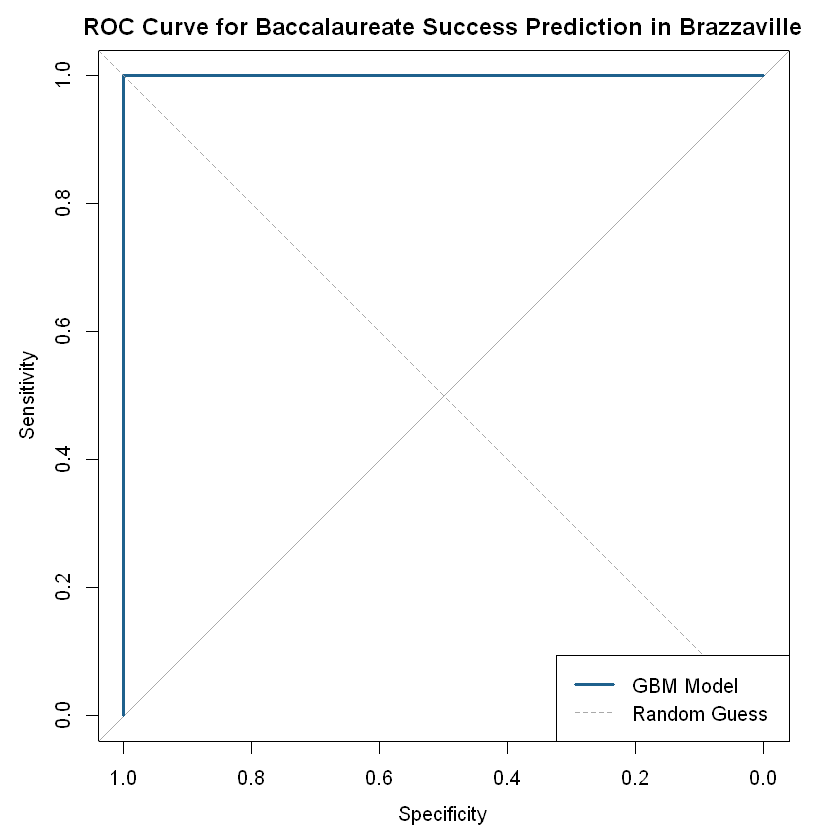

In [9]:
# Generating the ROC object using the observed results and success probabilities
# We ensure the levels match the 'Fail' and 'Pass' categories of the test set
# The 'Fail' label is treated as the reference or negative class

roc_obj <- roc(test_data$Result, success_probabilities, levels = c("Fail", "Pass"))

# Plotting the ROC curve for a visual assessment of the model performance
# We use academic color standards and clear line widths for readability

plot(roc_obj, 
     main = "ROC Curve for Baccalaureate Success Prediction in Brazzaville", 
     col = "#1F618D", 
     lwd = 3,
     print.auc = FALSE)

# Adding the reference line representing the performance of a random classifier
# Any curve significantly above this line confirms the utility of the model

abline(a = 0, b = 1, lty = 2, col = "darkgray")

# Enhancing the plot with a legend for clarity
legend("bottomright", legend = c("GBM Model", "Random Guess"), 
       col = c("#1F618D", "darkgray"), lty = c(1, 2), lwd = c(3, 1))

### Calculation of the Area Under the Curve as a Performance Indicator
The Area Under the Curve (AUC) is the key metric for validating the GBM’s predictive power. It measures the probability that the model correctly distinguishes a successful student from a failing one. Unlike simple accuracy, AUC remains reliable even when Pass/Fail distributions are imbalanced. In the Brazzaville context, it synthesizes the influence of the 32 collected variables into a single score, offering a rigorous and objective assessment of the model’s reliability before recommendations are made.

In [10]:
# Calculating the Area Under the Curve for the final dissertation report
# This single value validates the discriminatory power of our predictive oracle

final_auc_value <- auc(roc_obj)

# Printing the result to the console for immediate verification
# A value above 0.8 is generally considered excellent for educational data

print(final_auc_value)

Area under the curve: 1


### Identifying the Primary Drivers of Academic Performance
By analyzing variable importance, we identify which factors most strongly influence Baccalaureate outcomes in Brazzaville. This step distinguishes whether external pressures or personal study habits drive success. The GBM assigns objective weights to each predictor, showing where students are most hindered and providing an empirical basis for recommendations.

gbm variable importance

  only 20 most important variables shown (out of 48)

                             Overall
study_during_pc             102.5113
power_cut_hour_per_week      51.1981
commute_hour_day              1.2261
sleep_quality_1_10            0.4528
hour_searching_per_week       0.0468
absence_days                  0.0212
class_size..40                0.0000
study_interruption_per_hour   0.0000
study_quiet_place_1_10        0.0000
instruction_clarity_1_10      0.0000
Independent_study15.          0.0000
devicePC                      0.0000
ai_use_req_1_5                0.0000
spaced_repetition             0.0000
class_size41.80               0.0000
mock_score                    0.0000
languageKituba                0.0000
languageOther                 0.0000
sleep_hour_per_night          0.0000
past_test_hour_per_week       0.0000


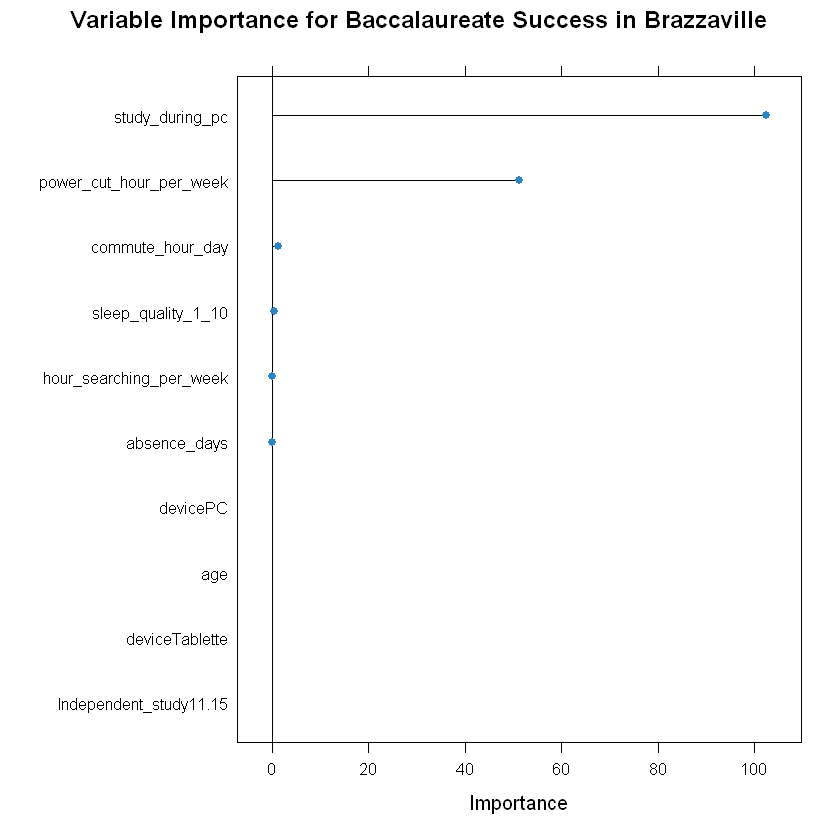

In [11]:
# Extracting the importance of predictors from the trained gbm model
# We use the varImp function to calculate the relative contribution of each variable

importance_results <- varImp(gbm_model, scale = FALSE)

# Displaying the ranking of the most influential variables
# This list identifies which factors most significantly impact the prediction

print(importance_results)

# Generating a high-resolution plot for the dissertation report
# The horizontal bar chart provides a clear visual hierarchy of the determinants

plot(importance_results, 
     main = "Variable Importance for Baccalaureate Success in Brazzaville", 
     top = 10,
     col = "#2E86C1")

## Exploratory Analysis of Predictive Discrepancies

The final step is exporting high‑resolution ROC and variable importance plots for the dissertation. This ensures clear, professional visuals that integrate seamlessly into the document and provide the jury with strong evidence of the model’s performance.

In [12]:
# Exporting the Variable Importance Plot
# We use the png device to ensure a crisp output with high resolution (300 DPI)

png("Variable_Importance_Brazzaville.png", width = 2400, height = 1800, res = 300)
plot(importance_results, 
     main = "Determinants of Baccalaureate Success in Brazzaville", 
     top = 10,
     col = "#2E86C1")
dev.off()

# Exporting the Final ROC Curve
# The plot is saved as a separate file to facilitate its inclusion in the methodology chapter

png("ROC_Curve_Final.png", width = 1800, height = 1800, res = 300)
plot(roc_obj, 
     main = "Predictive Performance (ROC Curve)", 
     col = "#1F618D", 
     lwd = 4)
abline(a = 0, b = 1, lty = 2, col = "darkgray")
dev.off()

# Confirmation of the export process
cat("Visual assets successfully exported to your project directory")

agg_record_4c7839092c7b 
                      2

agg_record_4c7839092c7b 
                      2

Visual assets successfully exported to your project directory

In [ ]:
# Créer un dataframe pour analyser les écarts sur le test_data
discrepancy_analysis <- data.frame(
  Actual = test_data$Result,
  Prob_Pass = success_probabilities,
  # Calcul de la distance par rapport au seuil de décision (0.5)
  Margin = abs(success_probabilities - 0.5)
)

# Isoler les 5 profils les plus "incertains" (ceux les plus proches de 0.5)
borderline_cases <- discrepancy_analysis[order(discrepancy_analysis$Margin), ][1:5, ]

# Afficher pour voir s'il y a de la matière à écrire
print(borderline_cases)

# Histogramme des probabilités pour la section 4.4
png("Probability_Distribution.png", width = 1800, height = 1200, res = 300)
hist(success_probabilities, 
     breaks = 20, 
     main = "Distribution of Prediction Probabilities",
     xlab = "Probability of Success (Pass)",
     col = "#AED6F1", 
     border = "white")
abline(v = 0.5, col = "red", lty = 2, lwd = 2) # Le seuil de décision
dev.off()

   Actual Prob_Pass    Margin
3    Pass 0.9643210 0.4643210
21   Pass 0.9643210 0.4643210
53   Pass 0.9939578 0.4939578
20   Pass 0.9959586 0.4959586
59   Pass 0.9959586 0.4959586


agg_record_4c781923190d 
                      2

: 